In [1]:
# Reproducibility: fix random seeds so training and outputs are deterministic
import numpy as np
import torch

SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# Use deterministic algorithms where available (may slightly reduce performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# The following warning can be safely ignored for current implementation
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="DataFrame.interpolate with object dtype is deprecated and will raise in a future version"
)

### Patient-level feature preprocessing

We standardize and enrich the static patient table (`patients.csv`) before merging it into the time-series pipeline:

- **Missing indicators first**: we create `bmi_missing` and `pain_missing` flags *before* filling any values so that missingness itself can be used as a signal. For categorical features, we add in another category for the encounters with missing values.
- **BMI imputation via regression**: BMI is imputed with a `HistGradientBoostingRegressor` using age, categorical demographics, and the `bmi_missing` flag as inputs. This leverages the strong correlation between BMI and other static features.
- **Pain score imputation via mean**: `pain_score` is filled with its mean. The distribution is skewed and shows only weak correlation with the remaining static variables, so a simple global mean works well in practice.
- **Numeric normalization**: all numeric static features (`age`, imputed `bmi`, imputed `pain_score`) are standardized with `StandardScaler`.
- **Static feature matrix**: these processed patient features (including the missing indicators) are then merged into the per-encounter training frame and later fed into the model as a static context vector.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# Load data
train = pd.read_csv("../data/train_data.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/test_data.csv", parse_dates=["timestamp"])
patients = pd.read_csv("../data/patients.csv")
train["__split__"] = "train"
test["__split__"] = "test"

# run the following for the final model trained on both train and test set
"""
all_data = pd.concat([train, test], axis=0, ignore_index=True, sort=False)
all_data.to_csv("../data/train_test_combined.csv", index=False)
print(f"Combined file saved: ../data/train_test_combined.csv ({len(all_data)} rows)")
# train = pd.read_csv("../data/train_test_combined.csv", parse_dates=["timestamp"])
"""

# Interpolate temporal features per encounter
features = [
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "respiratory_rate",
    "oxygen_saturation"
]

# Convert vitals to numeric (coerce errors)
for f in features:
    train[f] = pd.to_numeric(train[f], errors="coerce")

# Interpolate / ffill / bfill the full row to preserve encounter_id
train = (
    train
    .sort_values(["encounter_id", "timestamp"])
    .groupby("encounter_id", group_keys=False)
    .apply(lambda x: x.interpolate().ffill().bfill())
    .reset_index(drop=True)
)

# Ensure equal sequence length
seq_lengths = train.groupby("encounter_id").size()
if seq_lengths.nunique() != 1:
    raise ValueError("Encounter sequences have unequal lengths — cannot reshape safely.")

T = seq_lengths.iloc[0]
C = len(features)

# Prepare temporal vitals (X_vitals)
X_vitals = train[features].values.reshape(-1, T, C)
X_vitals = np.transpose(X_vitals, (0, 2, 1))  # (N_encounters, C, T)
X_vitals = X_vitals.astype(np.float32)

# Compute mean and std per channel across all encounters and timesteps
mean_vitals = X_vitals.mean(axis=(0, 2), keepdims=True)   # shape (1, C, 1)
std_vitals = X_vitals.std(axis=(0, 2), keepdims=True) + 1e-8  # shape (1, C, 1)

# Normalize training vitals
X_vitals = (X_vitals - mean_vitals) / std_vitals

# Prepare labels
y = train["label"].values.reshape(-1, T)
y = y.astype(np.float32)

# Patient feature preprocessing
patients["marital_status"] = patients["marital_status"].fillna("missing")

numeric_features = ["age", "bmi", "pain_score"]
categorical_features = [
    "gender",
    "race",
    "ethnicity",
    "encounter_description",
    "marital_status"
]

# Add missing indicators BEFORE imputation
patients["bmi_missing"] = patients["bmi"].isna().astype(int)
patients["pain_missing"] = patients["pain_score"].isna().astype(int)

# Encode categorical features
encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    patients[col] = le.fit_transform(patients[col].astype(str))
    encoders[col] = le

# BMI imputation (model-based)
feature_cols_bmi = ["age"] + categorical_features + ["bmi_missing"]

bmi_train = patients[patients["bmi"].notna()]

bmi_model = HistGradientBoostingRegressor(
    min_samples_leaf=50,
    max_leaf_nodes=127,
    max_iter=300,
    max_depth=None,
    learning_rate=0.01,
    random_state=123
)

bmi_model.fit(
    bmi_train[feature_cols_bmi],
    bmi_train["bmi"]
)

# Impute missing BMI
bmi_missing = patients["bmi"].isna()
patients.loc[bmi_missing, "bmi"] = bmi_model.predict(
    patients.loc[bmi_missing, feature_cols_bmi]
)

# Pain imputation (mean)
pain_mean = patients["pain_score"].mean()
patients["pain_score"] = patients["pain_score"].fillna(pain_mean)

# Normalize numeric features
patients[numeric_features] = patients[numeric_features].astype(np.float32)
scaler = StandardScaler()
patients[numeric_features] = scaler.fit_transform(patients[numeric_features])

# Merge patient features into train
patient_features_df = patients[
    ["encounter_id"] + numeric_features + categorical_features + ["bmi_missing", "pain_missing"]
]

train_with_patients = train.merge(
    patient_features_df,
    on="encounter_id",
    how="left"
)

# Extract patient-level features
patient_features = train_with_patients.groupby("encounter_id").first()[
    numeric_features + categorical_features + ["bmi_missing", "pain_missing"]
] .values.astype(np.float32)

P = patient_features.shape[1]

print("Pipeline complete: BMI model-based, Pain mean-imputed. All variables preserved; X_vitals, y, patient_features intact, no NaNs.")


C:\Users\yidi2\AppData\Local\Temp\ipykernel_15160\3227963077.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.interpolate().ffill().bfill())


Pipeline complete: BMI model-based, Pain mean-imputed. All variables preserved; X_vitals, y, patient_features intact, no NaNs.


### Clinical text features: TF–IDF with SVD

For the four clinical text fields (`previous_medical_history`, `current_medications`, `previous_medications`, `known_allergies`) plus `reason_for_visit`, we:

- **Fill missing entries** with the token `"none"` so that absence of text is explicit rather than treated as an empty string.
- **Lightly clean dosage tokens** (e.g. `10 MG`, `0.3 ML`) while preserving medication and concept names, to reduce sparsity without losing semantics.
- **Concatenate all text fields** into a single `clinical_text` string per patient so that TF–IDF can see cross-field co-occurrence patterns.
- **Apply TF–IDF vectorization** with a capped vocabulary (unigrams and bigrams, limited `max_features`) to keep the representation compact and robust.
- **Reduce dimensionality with TruncatedSVD** to a dense, low-rank embedding, which stabilizes training and makes the downstream CNN–BiGRU model less sensitive to the very high raw text dimensionality.

The resulting dense text embedding is then concatenated to the other static patient features before being passed to the model.

In [3]:
# Add clinical text features (reward-aligned optimal method)
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

text_cols = [
    "reason_for_visit",
    "previous_medical_history",
    "current_medications",
    "previous_medications",
    "known_allergies"
]

# Fill missing
patients[text_cols] = patients[text_cols].fillna("none")

# Light dosage cleaning (preserve medication names)
def clean_clinical_text(s):
    s = s.lower()
    s = re.sub(r"\d+\.?\d*\s*(mg|ml|unt|hr|day|%)", "", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

patients[text_cols] = patients[text_cols].apply(
    lambda col: col.apply(clean_clinical_text)
)

# Combine into single text field
patients["clinical_text"] = patients[text_cols].agg(" ".join, axis=1)

# TF-IDF (controlled dimensionality)
vectorizer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1, 2),
    min_df=5
)

X_text_sparse = vectorizer.fit_transform(patients["clinical_text"])

# Dimensionality reduction (critical for stability)
svd = TruncatedSVD(n_components=256, random_state=123)
X_text_reduced = svd.fit_transform(X_text_sparse)

X_text_reduced = X_text_reduced.astype(np.float32)

# Merge text features into patient_features
# Keep encounter_id alignment consistent
text_feature_df = pd.DataFrame(
    X_text_reduced,
    index=patients["encounter_id"]
)

text_feature_df = text_feature_df.reset_index()

train_with_text = train.merge(
    text_feature_df,
    on="encounter_id",
    how="left"
)

text_patient_features = train_with_text.groupby("encounter_id").first()[
    text_feature_df.columns[1:]
] .values.astype(np.float32)

# Concatenate with existing patient_features
patient_features = np.concatenate(
    [patient_features, text_patient_features],
    axis=1
)

P = patient_features.shape[1]

print("Clinical text features added.")
print("New patient feature dimension:", P)

Clinical text features added.
New patient feature dimension: 266


### Temporal encoder: CNN + BiGRU + multi-head attention

The final model combines convolutional and recurrent components with attention for sequence labelling:

- **CNN feature extractor**: a stack of 1D convolutions over time (stride `1`, symmetric padding) transforms the multi-channel vitals into a richer temporal embedding without downsampling. This keeps fine-grained information about state transitions between neighbouring timestamps.
- **Static feature encoder**: an MLP encodes the static patient vector (demographics, imputed BMI/pain, missing flags, and text-derived features) into a compact representation.
- **FiLM-style conditioning**: the static embedding is broadcast across the time axis and concatenated to the CNN output at each step, so every timestep sees both local vitals and global patient context.
- **BiGRU sequence model**: a 2-layer bidirectional GRU consumes the conditioned sequence, capturing forward and backward temporal dependencies in the encounter.
- **Multi-head self-attention block**: a `MultiheadAttention` layer refines the GRU outputs by letting each timestamp attend to all others, which helps model longer-range temporal interactions.
- **Per-timestep classifier**: a linear head maps the attended representation at each time index to the 4 target health states, yielding a full risk trajectory for the encounter.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Optimized CNN-BiGRU-Attention model
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, kernel_sizes=[5,5,3], dropout=0.1):
        super().__init__()
        layers = []
        current_channels = in_channels
        for k in kernel_sizes:
            layers.append(nn.Conv1d(current_channels, hidden_channels, kernel_size=k, padding=k//2, stride=1))  # stride=1!
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_channels))
            layers.append(nn.Dropout(dropout))
            current_channels = hidden_channels
        self.cnn = nn.Sequential(*layers)

    def forward(self, x):
        return self.cnn(x)

class StaticFeatureEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
    def forward(self, x):
        return self.mlp(x)

class GRN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.gate = nn.Linear(input_dim, input_dim)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        h = self.fc2(self.elu(self.fc1(x)))
        g = self.sigmoid(self.gate(x))
        return g * h + (1-g)*x

class CNN_BiGRU_Attention(nn.Module):
    def __init__(self, temporal_channels, static_channels, cnn_hidden=64, static_hidden=64, gru_hidden=128, n_heads=4, n_classes=4, dropout=0.1):
        super().__init__()
        self.cnn = CNNFeatureExtractor(temporal_channels, hidden_channels=cnn_hidden)
        self.static_encoder = StaticFeatureEncoder(static_channels, hidden_dim=static_hidden, dropout=dropout)
        self.gru = nn.GRU(input_size=cnn_hidden+static_hidden, hidden_size=gru_hidden, num_layers=2, batch_first=True, bidirectional=True, dropout=dropout)
        self.attn = nn.MultiheadAttention(embed_dim=gru_hidden*2, num_heads=n_heads, batch_first=True)
        self.layernorm = nn.LayerNorm(gru_hidden*2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gru_hidden*2, n_classes)

    def forward(self, x_temporal, x_static):
        cnn_out = self.cnn(x_temporal)  # (B, cnn_hidden, T)
        cnn_out_T = cnn_out.permute(0, 2, 1)  # (B, T, cnn_hidden)
        static_emb = self.static_encoder(x_static)  # (B, static_hidden)
        static_exp = static_emb.unsqueeze(1).expand(-1, cnn_out_T.size(1), -1)  # FiLM-style conditioning
        gru_in = torch.cat([cnn_out_T, static_exp], dim=-1)  # (B, T, cnn_hidden+static_hidden)
        gru_out, _ = self.gru(gru_in)  # (B, T, 2*gru_hidden)
        attn_out, _ = self.attn(gru_out, gru_out, gru_out)
        out = self.layernorm(attn_out + gru_out)
        out = self.dropout(out)
        logits = self.classifier(out).permute(0, 2, 1)  # (B, n_classes, T)
        return logits

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset tensors
X_tensor = torch.tensor(X_vitals, dtype=torch.float32)
patient_tensor = torch.tensor(patient_features, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

batch_size = 64
num_epochs = 100
g = torch.Generator().manual_seed(123)
dataset = TensorDataset(X_tensor, patient_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=g, num_workers=0, pin_memory=True)

# Reward matrix & loss
reward_matrix = torch.tensor([
    [ 0, -4, -2, -2],
    [-5,  2, -1, -3],
    [-7, -5,  3, -4],
    [-1, -1, -1,  1]
] , dtype=torch.float32, device=device)

def reward_loss(logits, targets):
    probs = torch.softmax(logits, dim=1)
    B, K, T = probs.shape
    probs_flat = probs.permute(0, 2, 1).reshape(-1, K)
    targets_flat = targets.reshape(-1)
    reward_rows = reward_matrix[targets_flat]
    expected_reward = (probs_flat * reward_rows).sum(dim=1)
    return -expected_reward.mean()

# Instantiate model
model = CNN_BiGRU_Attention(
    temporal_channels=X_tensor.shape[1],
    static_channels=patient_tensor.shape[1],
    cnn_hidden=64,
    static_hidden=64,
    gru_hidden=128,
    n_heads=4,
    n_classes=4,
    dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(loader), epochs=num_epochs)

# Training loop
loss_history = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    total_samples = 0
    for X_batch, patient_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        patient_batch = patient_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        logits = model(X_batch, patient_batch)
        loss = reward_loss(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        B = X_batch.size(0)
        epoch_loss += loss.item() * B
        total_samples += B
    epoch_loss /= total_samples
    loss_history.append(epoch_loss)
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss = {epoch_loss:.4f}")

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(range(num_epochs), loss_history, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.legend()
plt.show()

Using device: cpu
Epoch 0: Loss = 1.2763


KeyboardInterrupt: 

In [6]:
# Save trained model checkpoint (run after training)
from pathlib import Path
from datetime import datetime

checkpoint_dir = Path("./checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = checkpoint_dir / f"cnn_bigru_model_{timestamp}.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "num_epochs": num_epochs,
    "loss_history": loss_history,
}, checkpoint_path)

print(f"Checkpoint saved successfully.")

Checkpoint saved successfully.


### Perform model performance evaluation on the test set

In [7]:
# Load a trained CNN_BiGRU_Attention model from checkpoint

import torch
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for loading: {device}")

def load_trained_model(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)

    # Must match the architecture used during training
    model = CNN_BiGRU_Attention(
        temporal_channels=X_vitals.shape[1],   # C
        static_channels=patient_features.shape[1],  # P
        cnn_hidden=64,
        static_hidden=64,
        gru_hidden=128,
        n_heads=4,
        n_classes=4,
        dropout=0.1,
    ).to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded model from {checkpoint_path}")
    return model, checkpoint

# load the latest checkpoint from ./checkpoints
latest_ckpt = sorted(Path("./checkpoints").glob("cnn_bigru_model_*.pt"))[-1]
model, ckpt_info = load_trained_model(latest_ckpt)


Using device for loading: cuda
Loaded model from checkpoints\cnn_bigru_model_20260310_150309.pt


C:\Users\yidi2\AppData\Local\Temp\ipykernel_15160\3897794236.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.interpolate().ffill().bfill())


Total reward (sum): -135937.0
Accuracy: 0.7422381711855396


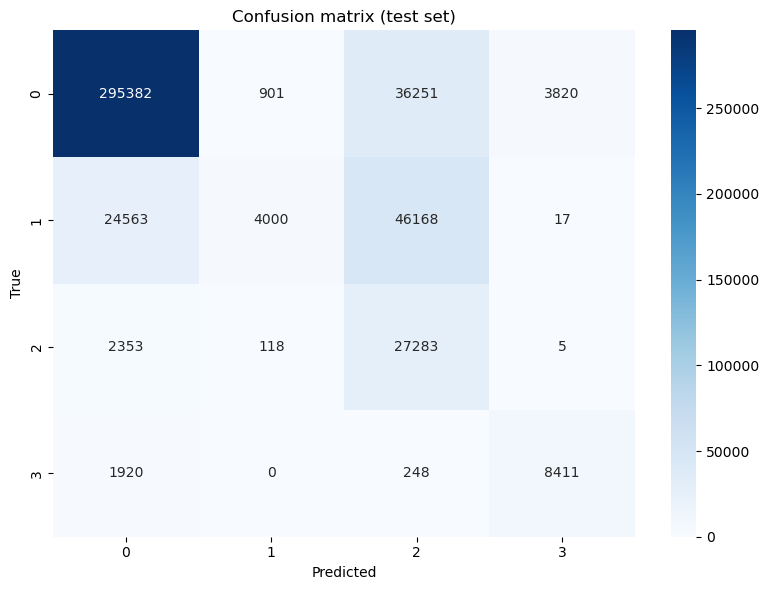

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test = pd.read_csv("../data/test_data.csv", parse_dates=["timestamp"])

# Prepare test temporal vitals
test["row_idx"] = np.arange(len(test))

# Ensure features are numeric
for f in features:
    test[f] = pd.to_numeric(test[f], errors="coerce")

# Interpolate/fill per encounter
test = (
    test.sort_values(["encounter_id", "timestamp"])
        .groupby("encounter_id", group_keys=False)
        .apply(lambda x: x.interpolate().ffill().bfill())
        .reset_index(drop=True)
)

# Sequence length check
T_test = test.groupby("encounter_id").size()
assert (T_test == T).all(), "Test encounters must have same T as training"

# Row mapping
row_ids_test = np.stack(
    test.groupby("encounter_id", sort=False)["row_idx"].apply(lambda x: x.values)
)

# Prepare X_vitals
X_vitals_test = np.stack(
    test.groupby("encounter_id", sort=False)[features].apply(lambda x: x.values)
)
X_vitals_test = np.transpose(X_vitals_test, (0, 2, 1))  # (N_encounters, C, T)
X_vitals_test = X_vitals_test.astype(np.float32)
X_vitals_test = (X_vitals_test - mean_vitals) / std_vitals  # normalize

# Prepare patient features (from already preprocessed patients)
# Numeric + categorical + missing flags (same as training)
base_patient_df = patients[
    ["encounter_id"] + numeric_features + categorical_features + ["bmi_missing", "pain_missing"]
]

test_with_patients = test.merge(
    base_patient_df,
    on="encounter_id",
    how="left",
)

base_patient_features_test = (
    test_with_patients
    .groupby("encounter_id", sort=False)
    .first()[numeric_features + categorical_features + ["bmi_missing", "pain_missing"]]
    .values.astype(np.float32)
)

# Text features for ALL patients using the SAME vectorizer & SVD as training
# (vectorizer and svd are already fitted earlier in the notebook)

X_text_sparse_test = vectorizer.transform(patients["clinical_text"])
X_text_reduced_test = svd.transform(X_text_sparse_test).astype(np.float32)

text_feature_df_test = pd.DataFrame(
    X_text_reduced_test,
    index=patients["encounter_id"]
).reset_index()

test_with_text = test.merge(
    text_feature_df_test,
    on="encounter_id",
    how="left"
)

text_patient_features_test = (
    test_with_text
    .groupby("encounter_id", sort=False)
    .first()[text_feature_df_test.columns[1:]]  # drop encounter_id
    .values.astype(np.float32)
)

# Concatenate to match training order and dimension
patient_features_test = np.concatenate(
    [base_patient_features_test, text_patient_features_test],
    axis=1
).astype(np.float32)

# later:
P_t = torch.tensor(patient_features_test, dtype=torch.float32)

# True labels per encounter
y_true_per_enc = np.stack(
    test.groupby("encounter_id", sort=False)["label"].apply(lambda x: x.values.astype(np.int64))
)

# Model inference
model = model.to(device)
model.eval()
X_v_t = torch.tensor(X_vitals_test, dtype=torch.float32, device=device)
P_t = torch.tensor(patient_features_test, dtype=torch.float32, device=device)

batch_size = 64
all_logits = []

with torch.no_grad():
    for i in range(0, len(X_v_t), batch_size):
        xb = X_v_t[i : i + batch_size]
        pb = P_t[i : i + batch_size]
        logits = model(xb, pb)  # (B, n_classes, T)
        all_logits.append(logits)

all_logits = torch.cat(all_logits, dim=0)  # (N_encounters, n_classes, T)
preds_per_enc = all_logits.argmax(dim=1).cpu().numpy()  # (N_encounters, T)

# Map predictions back to row order (vectorized)
n_rows_test = int(test["row_idx"].max()) + 1
all_preds_test = np.empty(n_rows_test, dtype=np.int64)
all_true_test = np.empty(n_rows_test, dtype=np.int64)

for e, row_ids in enumerate(row_ids_test):
    all_preds_test[row_ids] = preds_per_enc[e]
    all_true_test[row_ids] = y_true_per_enc[e]

# Total reward
reward_matrix_true = np.array([
    [0, -2, -2, -2],
    [-3, 2, -1, -3],
    [-10, -3, 3, -10],
    [0, 0, 0, 0]
], dtype=np.float32)

total_reward = reward_matrix_true[all_true_test, all_preds_test].sum()
print("Total reward (sum):", total_reward)

# Accuracy
accuracy = (all_preds_test == all_true_test).mean()
print("Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(all_true_test, all_preds_test, labels=[0,1,2,3])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

### Produce prediction results for the holdout set

In [9]:
import pandas as pd
import numpy as np
import torch

# Load + preprocess holdout temporals
holdout = pd.read_csv("../data/holdout_data.csv", parse_dates=["timestamp"])
holdout["row_idx"] = np.arange(len(holdout))

# Ensure features are numeric
for f in features:
    holdout[f] = pd.to_numeric(holdout[f], errors="coerce")

# Interpolate per encounter
holdout = (
    holdout.sort_values(["encounter_id", "timestamp"])
           .groupby("encounter_id", group_keys=False)
           .apply(lambda x: x.interpolate().ffill().bfill())
           .reset_index(drop=True)
)

# Sequence length check
T_holdout = holdout.groupby("encounter_id").size()
assert (T_holdout == T).all(), "Holdout encounters must have same T as train"

# Row mapping
row_ids_holdout = np.stack(
    holdout.groupby("encounter_id", sort=False)["row_idx"].apply(lambda x: x.values)
)

# Temporal vitals tensor
X_vitals_holdout = np.stack(
    holdout.groupby("encounter_id", sort=False)[features].apply(lambda x: x.values)
)
X_vitals_holdout = np.transpose(X_vitals_holdout, (0, 2, 1))  # (N, C, T)
X_vitals_holdout = X_vitals_holdout.astype(np.float32)
X_vitals_holdout = (X_vitals_holdout - mean_vitals) / std_vitals  # normalize

# Patient features (same pipeline as train/test)
# Numeric + categorical + missing flags from globally preprocessed `patients`
base_patient_df = patients[
    ["encounter_id"] + numeric_features + categorical_features + ["bmi_missing", "pain_missing"]
]

holdout_with_patients = holdout.merge(
    base_patient_df,
    on="encounter_id",
    how="left",
)

base_patient_features_holdout = (
    holdout_with_patients
    .groupby("encounter_id", sort=False)
    .first()[numeric_features + categorical_features + ["bmi_missing", "pain_missing"]]
    .values.astype(np.float32)
)

# Text features using same vectorizer + SVD as training
X_text_sparse_holdout = vectorizer.transform(patients["clinical_text"])
X_text_reduced_holdout = svd.transform(X_text_sparse_holdout).astype(np.float32)

text_feature_df_holdout = pd.DataFrame(
    X_text_reduced_holdout,
    index=patients["encounter_id"]
).reset_index()

holdout_with_text = holdout.merge(
    text_feature_df_holdout,
    on="encounter_id",
    how="left"
)

text_patient_features_holdout = (
    holdout_with_text
    .groupby("encounter_id", sort=False)
    .first()[text_feature_df_holdout.columns[1:]]  # drop encounter_id
    .values.astype(np.float32)
)

# Concatenate to match training static dimension
patient_features_holdout = np.concatenate(
    [base_patient_features_holdout, text_patient_features_holdout],
    axis=1
).astype(np.float32)

# Model inference
model = model.to(device)
model.eval()
X_v_t = torch.tensor(X_vitals_holdout, dtype=torch.float32, device=device)
P_t = torch.tensor(patient_features_holdout, dtype=torch.float32, device=device)

batch_size = 64
all_logits = []

with torch.no_grad():
    for i in range(0, len(X_v_t), batch_size):
        xb = X_v_t[i: i + batch_size]
        pb = P_t[i: i + batch_size]
        logits = model(xb, pb)  # (B, n_classes, T)
        all_logits.append(logits)

all_logits = torch.cat(all_logits, dim=0)  # (N_encounters, n_classes, T)
preds_per_enc = all_logits.argmax(dim=1).cpu().numpy()  # (N_encounters, T)

# Map predictions back to rows
n_rows_holdout = int(holdout["row_idx"].max()) + 1
all_preds_holdout = np.empty(n_rows_holdout, dtype=np.int64)

for e in range(preds_per_enc.shape[0]):
    for t in range(preds_per_enc.shape[1]):
        r = row_ids_holdout[e, t]
        all_preds_holdout[r] = preds_per_enc[e, t]

# Save submission
submission = pd.DataFrame({
    "ID": np.arange(n_rows_holdout),
    "predicted_label": all_preds_holdout,
})
submission.to_csv("holdout_predictions.csv", index=False)
print("Saved predictions to holdout_predictions.csv")

C:\Users\yidi2\AppData\Local\Temp\ipykernel_15160\2895713772.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.interpolate().ffill().bfill())


Saved predictions to holdout_predictions.csv
